# Import Packages (baseline model)

In [ ]:
import sys
print(sys.executable)

c:\Users\xin37\github\CNN-LSTM-model-for-energy-usage-forecasting-1\venv\Scripts\python.exe


In [1]:
# univariate multi-step CNN-LSTM for energy usage forecasting

import time

# Start counting notebook running time
time_start = time.time()

import numpy as np
import tensorflow as tf
# Set all random seeds for the program (Python, NumPy, and TensorFlow)
tf.keras.utils.set_random_seed(1)

import pandas as pd
from  IPython.display import display, Image
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

from keras.models import Sequential
from keras.layers import Dense, Flatten, LSTM, RepeatVector, TimeDistributed
from keras.layers import Conv1D, MaxPooling1D
from keras.utils import plot_model

In [2]:
print(tf.__version__)

2.21.0


# Import Data¶
## Daily power data of all campus buildings of IIT Delhi

In [3]:
%%time
df = pd.read_csv(
    'C:\\Users\\xin37\\github\\CNN-LSTM-model-for-energy-usage-forecasting-1\\data\\HVAC_NE_EC_19-21.csv', 
    header=0, 
    parse_dates=['Timestamp'], 
    index_col=['Timestamp']
    ) 
print(df.shape)
display(df.head())

(33888, 10)


,T_Supply,T_Return,SP_Return,T_Saturation,T_Outdoor,RH_Supply,RH_Return,RH_Outdoor,Energy,Power
Timestamp,,,,,,,,,,
2019-10-15 00:00:00+02:00,19.859999,20.469999,18.5,19.02,20.299999,71.110001,58.919998,79.5,0.0,0.0
2019-10-15 00:15:00+02:00,19.855000,20.430000,18.5,19.02,20.299999,71.320000,59.000000,82.0,0.0,0.0
2019-10-15 00:30:00+02:00,19.850000,20.410000,18.5,19.02,20.299999,71.470001,59.109997,79.5,0.0,0.0
2019-10-15 00:45:00+02:00,19.840000,20.379999,18.5,19.08,20.299999,71.439995,59.309998,77.0,0.0,0.0
2019-10-15 01:00:00+02:00,19.830000,20.350000,18.5,19.08,20.299999,71.580002,59.559998,79.5,0.0,0.0


CPU times: total: 172 ms
Wall time: 169 ms


In [4]:
df.index = pd.to_datetime(df.index, utc=True)

# Visualize sample data

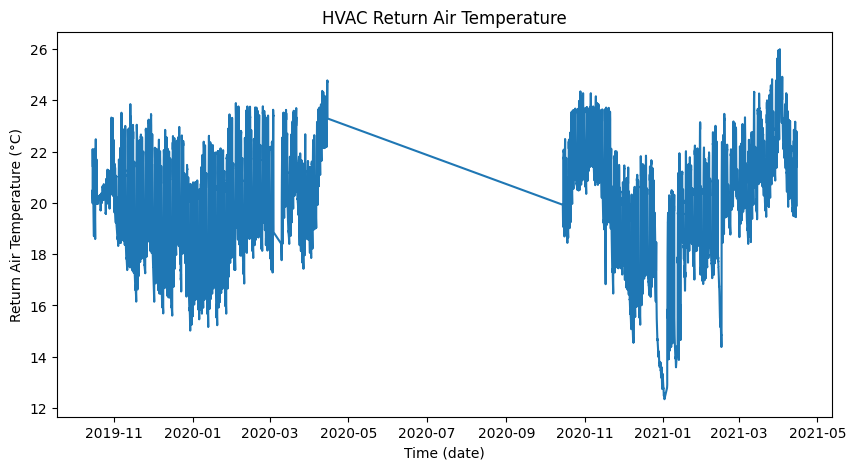

CPU times: total: 297 ms
Wall time: 302 ms


In [5]:
%%time
fig = plt.figure(figsize=(10, 5));
plt.plot(df.index, df['T_Return'])
plt.xlabel('Time (date)')
plt.ylabel('Return Air Temperature (°C)')
plt.title('HVAC Return Air Temperature')
plt.show()

# Split a dataset into train/test sets

In [6]:
# number of weeks in training data
nwt = len(df) // 7

# Number of weeks in test data (predictions will be made and compared)
nwp = 96

# split dataset into train and test sets
def split_dataset(data, n_output):
    # slice dataset as multiples of output sequence 
    data = data.tail(n_output*nwt) # 
    # split into train and test set
    train = np.array(data.iloc[:-n_output*nwp])
    test =  np.array(data.iloc[-n_output*nwp:-n_output] )
    return train, test

In [7]:
train, test = split_dataset(df, n_output=7)
print(train.shape)
print(test.shape)

(33215, 10)
(665, 10)


#  Format the data in the overlapping moving window format¶
We need to restrucutre the time-series data in order for training and making predictions like a supervised machine learning model. For every n_input sequence of data, the n_ouput sequence will be target values. We will also increment the sequences by 1 each time to utilise the so called overlapping window format.

In [9]:
# convert data into input and output steps
def transform_data(train, n_input, n_output):
    X, y = [], []
    # loop over the data by 1 time step
    for i in range(len(train)):
        # define the index range of the input 
        in_end = i + n_input
        out_end = in_end + n_output
        if out_end <= len(train):
            x_input = train[i:in_end, 0] # only one feature/column is selected 
            x_input = x_input.reshape((len(x_input), 1))
            X.append(x_input)
            y.append(train[in_end:out_end, 0])
    return np.array(X), np.array(y)


# Define function for building model
In this model architecture, a one-dimensional convolutional neural network (1D CNN) is used to read and encode the input sequence. An LSTM network is then used as a decoder to make ode-step prediction for each value in the output sequence. 

In [10]:
# build and train the model
def build_model(train, n_input, n_output):
    # transform data
    X_train, y_train = transform_data(train, n_input, n_output)
    # specify model parameters
    verbose, epochs, batch_size = 0, 100, 16
    n_features = X_train.shape[2]
    # reshape output into [samples, timesteps, features]
    y_train = y_train.reshape((y_train.shape[0], y_train.shape[1], 1))
    # define model
    model = Sequential()
    #-------CNN-------
    model.add(Conv1D(32, 3, activation='relu', input_shape=(n_input, n_features)))
    model.add(Conv1D(32, 3, activation='relu'))
    model.add(MaxPooling1D())
    model.add(Flatten())
    #-------CNN-------
    #-------LSTM-------
    model.add(RepeatVector(n_output))
    model.add(LSTM(200, activation='relu', return_sequences=True))
    #-------LSTM-------
    model.add(TimeDistributed(Dense(100, activation='relu')))
    model.add(TimeDistributed(Dense(1)))
    model.compile(loss='mse', optimizer='adam')
    print(model.summary())
    plot_model(model=model, to_file ='model_CNN-LSTM_univariate_multistep_output.png', show_shapes=True, show_layer_names=True)
    # fit network
    # --- CHANGED: Save the training process to 'history' ---
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1)
    return model, history

# Define function for evaluating model

In [11]:
# define function for evaluating the model
def evaluate_model(train, test, n_input, n_output):
    # fit the model on training data
    model, history = build_model(train, n_input, n_output)
    input_data = train.copy()
    # make predictions for each sequence (week) with a walk-forward approach
    predictions = []
    for i in range(int(len(test)/n_output)+1):
        input_x = input_data[-n_input : ,  0]
        # reshape input data 
        input_x = input_x.reshape((1, len(input_x), 1))
        # predict the sequence 
        yhat = model.predict(input_x, verbose=0)
        # get the vector output of the sequence
        yhat_sequence = yhat[0]
        # store the predicted values for each iteration in predictions
        predictions.append(yhat_sequence)
        # add the sequence of test data (for whcih prediction has just been made in the last iteration) to input data to make predictions for the next sequence
        if i < len(test)/n_output:
            input_data = np.append(input_data, test[i*n_output:(i+1)*n_output, :], axis=0) 
    # convert predictions to numpy array
    predictions = np.array(predictions)
    return predictions, history

# Train model and make predictions

c:\Users\xin37\github\CNN-LSTM-model-for-energy-usage-forecasting-1\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 19, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 17, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 7, 200)         │       365,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 7, 100)         │        20,100 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 7, 1)           │           101 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 389,033 (1.48 MB)

 Trainable params: 389,033 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

None
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Epoch 1/100
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 4.2800
Epoch 2/100
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 2.3942
Epoch 3/100
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 2.2853
Epoch 4/100
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 2.2387
Epoch 5/100
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 2.1918
Epoch 6/100
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 2.1686
Epoch 7/100
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 2.1430
Epoch 8/100
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 2.1164
Epoch 9/100
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 2.0950
Epoch 10/100
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 2.0811
Epoch 11/100
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 2.0523
Epoch 12/100
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 2.0342
Epoch 13/100
2075/2075 ━━━━━━

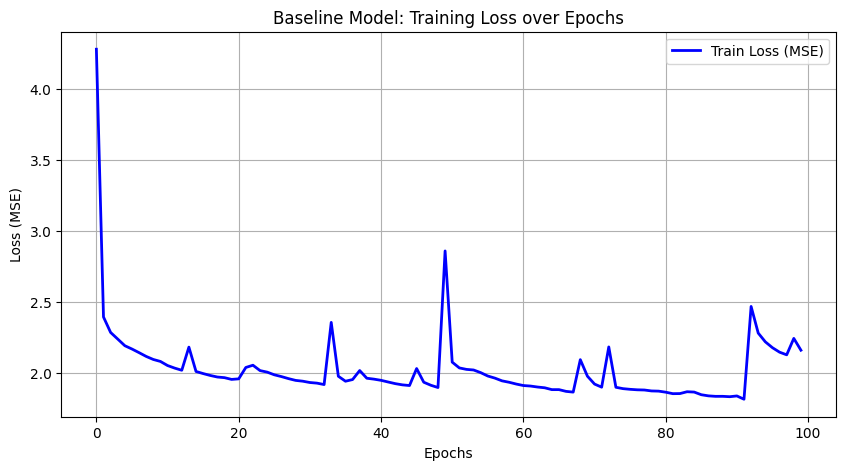

CPU times: total: 1h 52min 1s
Wall time: 44min 21s


In [12]:
%%time
n_output = 7
n_input = n_output*3

# split into train and test
train, test = split_dataset(df, n_output)

# evaluate model and get scores
predictions, history = evaluate_model(train, test, n_input, n_output)
print('number of weeks predicted: ', len(predictions))

plt.figure(figsize=(10, 5))
# Note: The baseline model doesn't use validation data, so we only plot 'loss'
plt.plot(history.history['loss'], label='Train Loss (MSE)', color='blue', linewidth=2)
plt.title('Baseline Model: Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Visualize model architecture

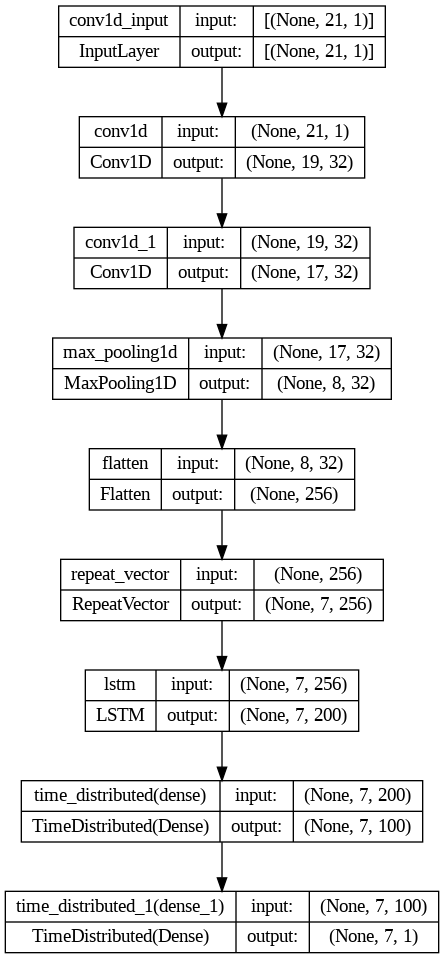

In [ ]:
Image('model_CNN-LSTM_univariate_multistep_output.png')

# Compare actual and predicted values

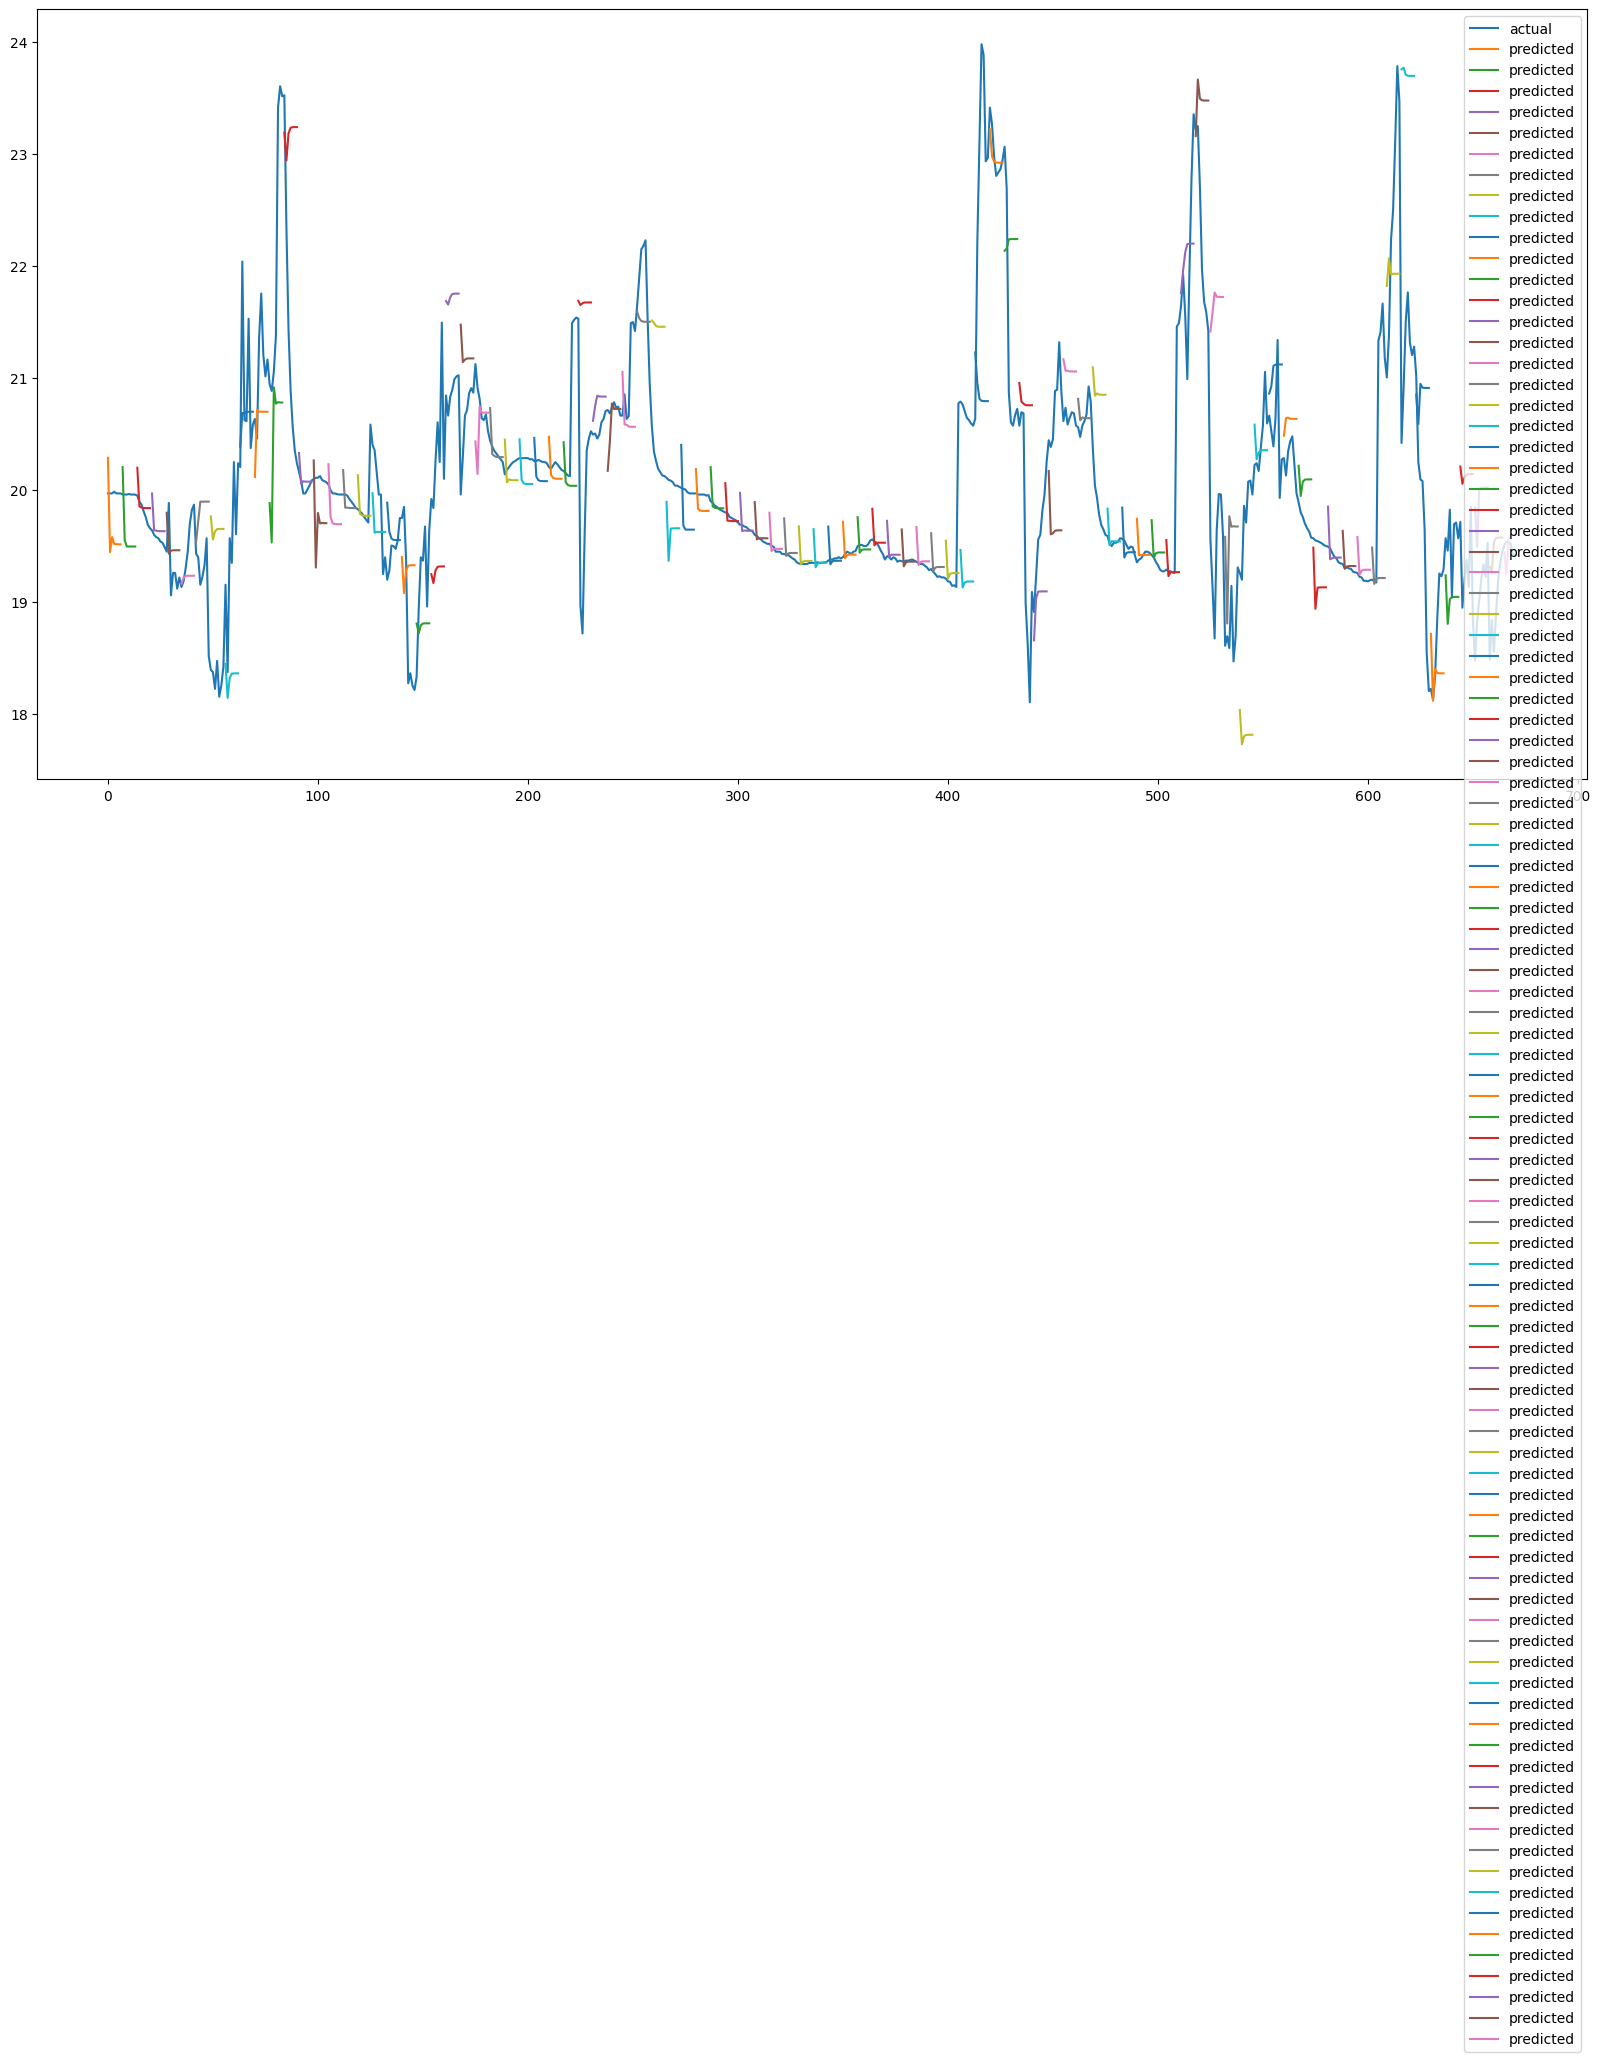

In [13]:
def plot_predictions(actual, predicted):
    fig = plt.figure(figsize=(20,10))
    plt.plot(actual, label='actual')
    for i in range(0, len(predicted), n_output):
        plt.plot(np.array(range(0+i, i+n_output)), predicted[0+i : i+n_output], label = 'predicted')
    plt.legend()
    plt.show()

# flatten actual and predictions data 
actual = df.tail(nwp*n_output).iloc[: , 0].values
# actual_flat = actual.reshape(actual.shape[0]*actual.shape[1])
predictions_flat = predictions.reshape(predictions.shape[0]*predictions.shape[1])

# plot actual vs predicted
plot_predictions(actual, predictions_flat)

# RMSE for all sequences

In [ ]:
def return_rmse(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print("The root mean squared error is {:.2f}.".format(rmse))
    
return_rmse(actual, predictions_flat)

The root mean squared error is 0.86.


In [15]:
time_end = time.time()
print("Notebook run time: {:.0f} seconds".format(time_end - time_start))

Notebook run time: 3347 seconds


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate metrics using the flattened arrays from your baseline code
mae_base = mean_absolute_error(actual, predictions_flat)
mse_base = mean_squared_error(actual, predictions_flat)
rmse_base = np.sqrt(mse_base)
r2_base = r2_score(actual, predictions_flat)

print("--- BASELINE MODEL PERFORMANCE ---")
print(f"Mean Absolute Error (MAE): {mae_base:.4f}")
print(f"Mean Squared Error (MSE):  {mse_base:.4f}")
print(f"Root Mean Squared Error:   {rmse_base:.4f}")
print(f"R-squared Score (R2):      {r2_base:.4f}")

--- BASELINE MODEL PERFORMANCE ---
Mean Absolute Error (MAE): 0.5388
Mean Squared Error (MSE):  0.7383
Root Mean Squared Error:   0.8592
R-squared Score (R2):      0.2407
